<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec13_Case_Study_on_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🔄 What Happens During Data Preprocessing?

In this bootcamp, you will learn how to:

- 📊 Understand the dataset structure  
- ❓ Handle missing values correctly  
- 🚨 Detect and treat outliers  
- 🔤 Encode categorical variables  
- 📐 Scale and normalize numerical features  
- 🗑️ Remove irrelevant or redundant columns  
- 🤖 Prepare data suitable for machine learning algorithms  


In [ ]:
import pandas as pd

data = {
    "House_ID": [
        "H001","H002","H003","H004","H005",
        "H006","H007","H008","H009","H010",
        "H011","H012","H013","H014","H015",
        "H016","H017","H018","H019","H020",
        "H021","H022","H023","H024","H025",
        "H003","H006"
    ],

    "House_Name": [
        "Green Villa","Sai Nivas","Oak Residency","Lake View House","Blue Horizon",
        "Palm Heights","Sneha Bhavan","River Side Home","Sunset Villa","Elite Enclave",
        "Silver Nest","Green Acres","Royal Meadows","Lotus Home","Coral Residency",
        "Peace Haven","Emerald House","Golden Nest","Morning Glory","Hill Crest",
        "White Pearl","Comfort Stay","Urban Nest","Serene Homes","Grand Pavilion",
        "Oak Residency","Palm Heights"
    ],

    "Owner_Name": [
        "Rajesh Kumar","Anita Menon","Rohit Sharma","Suresh Nair","Arvind Iyer",
        "Deepak Varma","Manoj Pillai","Neethu Krishnan","Amit Patel","Karthik R",
        "Ajith Mohan","Priya Suresh","Nikhil Jain","Bindu Ramesh","Shyam Menon",
        "Santhosh K","Vivek Malhotra","Anjali Nair","Ramesh Das","Prakash Rao",
        "Sandeep Verma","Rekha N","Faizal Khan","Anu Joseph","Mahesh Babu",
        "Rohit Sharma","Deepak Varma"
    ],

    "Area_sqft": [
        850,1200,1500,None,1800,
        1100,700,1400,2000,1600,
        950,1250,1750,1000,1450,
        850,1900,1300,1050,1550,
        2100,900,1650,1150,1850,
        1500,1100
    ],

    "Bedrooms": [
        2,3,3,2,4,
        2,1,None,4,3,
        2,3,4,2,3,
        2,4,3,2,3,
        5,2,3,2,4,
        3,2
    ],

    "Bathrooms": [
        1,2,3,2,3,
        2,1,2,4,3,
        None,2,3,2,2,
        1,4,2,2,3,
        4,1,3,2,3,
        3,2
    ],

    "Location": [
        "Kochi","Trivandrum","Bangalore","Kollam","Chennai",
        "Kochi","Kollam","Trivandrum","Bangalore","Chennai",
        "Kochi","Trivandrum","Bangalore","Kollam","Chennai",
        None,"Bangalore","Trivandrum","Kollam","Chennai",
        "Bangalore","Kochi","Trivandrum","Kollam","Chennai",
        "Bangalore","Kochi"
    ],

    "Property_Type": [
        "Apartment","Apartment","Independent","Apartment","Independent",
        "Apartment","Apartment","Apartment","Villa","Independent",
        "Apartment","Apartment","Villa","Apartment","Apartment",
        "Apartment","Independent","Apartment","Apartment","Independent",
        "Villa","Apartment","Independent","Apartment","Independent",
        "Independent","Apartment"
    ],

    "Floor": [
        3,5,1,2,2,
        7,1,4,1,3,
        2,6,2,3,5,
        1,2,4,2,1,
        1,3,2,4,2,
        1,7
    ],

    "House_Warming_Date": [
        "2014-06-15","2019-09-10","2022-01-20","2008-03-05","2016-11-25",
        "2018-07-12","2003-05-18","2017-02-14",None,"2011-08-09",
        "2006-10-30",None,"2020-12-05","2013-06-22","2015-09-17",
        "2001-01-10","2021-03-28","2018-05-06","2010-12-19","2012-04-11",
        "2022-08-15",None,"2019-01-09","2016-06-30","2017-10-21",
        "2022-01-20","2018-07-12"
    ],

    "Parking": [
        "Yes","Yes","Yes","No","Yes",
        None,"No","Yes","Yes","Yes",
        "No","Yes","Yes","No","Yes",
        "No","Yes","Yes","No","Yes",
        "Yes","No","Yes","No","Yes",
        "Yes","Yes"
    ],

    "Near_Metro": [
        "Yes","No","Yes","No","Yes",
        "Yes","No","Yes","Yes","No",
        "No","Yes",None,"No","Yes",
        "No","Yes","Yes","No","No",
        "Yes","No","Yes","No","Yes",
        "Yes","Yes"
    ],

    "House_Price": [
        4500000,6200000,9800000,3800000,11500000,
        6800000,3000000,7500000,15000000,10200000,
        4100000,7000000,13500000,4200000,8200000,
        3600000,14200000,7700000,4600000,9500000,
        16500000,3900000,8800000,5100000,12000000,
        9800000,6800000
    ]
}

df = pd.DataFrame(data)
df.head()
# understand all feature/ columns

,House_ID,House_Name,Owner_Name,Area_sqft,Bedrooms,Bathrooms,Location,Property_Type,Floor,House_Warming_Date,Parking,Near_Metro,House_Price
0,H001,Green Villa,Rajesh Kumar,850.0,2.0,1.0,Kochi,Apartment,3,2014-06-15,Yes,Yes,4500000
1,H002,Sai Nivas,Anita Menon,1200.0,3.0,2.0,Trivandrum,Apartment,5,2019-09-10,Yes,No,6200000
2,H003,Oak Residency,Rohit Sharma,1500.0,3.0,3.0,Bangalore,Independent,1,2022-01-20,Yes,Yes,9800000
3,H004,Lake View House,Suresh Nair,NaN,2.0,2.0,Kollam,Apartment,2,2008-03-05,No,No,3800000
4,H005,Blue Horizon,Arvind Iyer,1800.0,4.0,3.0,Chennai,Independent,2,2016-11-25,Yes,Yes,11500000


**Steps in data preprocessing**:
1. Duplicates
2. Missing Values
3. handling date datatype
4. Feature selection
5. Outlier
6. Visualization insight
7. Encoding
8. Scaling

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   House_ID            27 non-null     object 
 1   House_Name          27 non-null     object 
 2   Owner_Name          27 non-null     object 
 3   Area_sqft           26 non-null     float64
 4   Bedrooms            26 non-null     float64
 5   Bathrooms           26 non-null     float64
 6   Location            26 non-null     object 
 7   Property_Type       27 non-null     object 
 8   Floor               27 non-null     int64  
 9   House_Warming_Date  24 non-null     object 
 10  Parking             26 non-null     object 
 11  Near_Metro          26 non-null     object 
 12  House_Price         27 non-null     int64  
dtypes: float64(3), int64(2), object(8)
memory usage: 2.9+ KB


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
House_ID,0
House_Name,0
Owner_Name,0
Area_sqft,1
Bedrooms,1
Bathrooms,1
Location,1
Property_Type,0
Floor,0
House_Warming_Date,3


In [ ]:
df.isnull().mean()*100

,0
House_ID,0.000000
House_Name,0.000000
Owner_Name,0.000000
Area_sqft,3.846154
Bedrooms,3.846154
Bathrooms,3.846154
Location,3.846154
Property_Type,0.000000
Floor,0.000000
House_Warming_Date,11.538462


In [ ]:
from sklearn.impute import SimpleImputer


In [ ]:
# Numerical columns
num_cols = [
    "Area_sqft", "Bedrooms", "Bathrooms",
    "Floor", "House_Price"
]

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns.tolist()

# Date column
date_col = ["House_Warming_Date"]


In [ ]:
cat_cols

['House_ID',
 'House_Name',
 'Owner_Name',
 'Location',
 'Property_Type',
 'House_Warming_Date',
 'Parking',
 'Near_Metro']

In [ ]:
num_imputer = SimpleImputer(strategy="median")

df[num_cols] = num_imputer.fit_transform(df[num_cols])


In [ ]:
cat_imputer = SimpleImputer(strategy="most_frequent")

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [ ]:
cat_imputer

SimpleImputer(strategy='most_frequent')

In [ ]:
df.isnull().sum()

,0
House_ID,0
House_Name,0
Owner_Name,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Location,1
Property_Type,0
Floor,0
House_Warming_Date,3


In [ ]:
print(df["Location"].value_counts())

Location
Kochi         5
Trivandrum    5
Bangalore     5
Kollam        5
Chennai       5
Name: count, dtype: int64


In [ ]:
df["Parking"].value_counts()

,count
Parking,
Yes,17
No,8


In [ ]:
import statistics as st
st.mode(df["Parking"])

'Yes'

In [ ]:

df["Parking"] = df["Parking"].fillna(df["Parking"].mode()[0])
df["Near_Metro"] = df["Near_Metro"].fillna(df["Near_Metro"].mode()[0])


In [ ]:
# Fill missing with most frequent
most_freq_date = df["House_Warming_Date"].mode()[0]
df["House_Warming_Date"].fillna(most_freq_date, inplace=True)


/tmp/ipykernel_795/770544138.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["House_Warming_Date"].fillna(most_freq_date, inplace=True)


In [ ]:
df.isnull().sum()

,0
House_ID,0
House_Name,0
Owner_Name,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Location,1
Property_Type,0
Floor,0
House_Warming_Date,0


In [ ]:
df["Location"].value_counts()

,count
Location,
Kochi,5
Trivandrum,5
Bangalore,5
Kollam,5
Chennai,5


In [ ]:
df["Location"].mode()
# Kochi, Trivandrum, Bangalore, Kollam, Chennai


,Location
0,Bangalore
1,Chennai
2,Kochi
3,Kollam
4,Trivandrum


In [ ]:
df["Location"].nunique()

5

In [ ]:
import pandas as pd
import numpy as np
np.random.choice(
    df["Location"]) #may contain nan

'Trivandrum'

In [ ]:
import numpy as np
np.random.choice(df["Location"]) #may contain nan

'Trivandrum'

In [ ]:
import numpy as np

df.loc[df["Location"].isna(), "Location"] = np.random.choice(df["Location"].dropna())
df.isnull().sum()

,0
House_ID,0
House_Name,0
Owner_Name,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Location,0
Property_Type,0
Floor,0
House_Warming_Date,0


# missing value handled

In [ ]:
df["House_Warming_Date"] = pd.to_datetime(df["House_Warming_Date"])
today = pd.Timestamp.today()
df["age_of_house"] = today - df["House_Warming_Date"]


In [ ]:
df

,House_ID,House_Name,Owner_Name,Area_sqft,Bedrooms,Bathrooms,Location,Property_Type,Floor,House_Warming_Date,Parking,Near_Metro,House_Price,age_of_house
0,H001,Green Villa,Rajesh Kumar,850.0,2.0,1.0,Kochi,Apartment,3.0,2014-06-15,Yes,Yes,4500000.0,4280 days 06:15:39.722442
1,H002,Sai Nivas,Anita Menon,1200.0,3.0,2.0,Trivandrum,Apartment,5.0,2019-09-10,Yes,No,6200000.0,2367 days 06:15:39.722442
2,H003,Oak Residency,Rohit Sharma,1500.0,3.0,3.0,Bangalore,Independent,1.0,2022-01-20,Yes,Yes,9800000.0,1504 days 06:15:39.722442
3,H004,Lake View House,Suresh Nair,1300.0,2.0,2.0,Kollam,Apartment,2.0,2008-03-05,No,No,3800000.0,6573 days 06:15:39.722442
4,H005,Blue Horizon,Arvind Iyer,1800.0,4.0,3.0,Chennai,Independent,2.0,2016-11-25,Yes,Yes,11500000.0,3386 days 06:15:39.722442
5,H006,Palm Heights,Deepak Varma,1100.0,2.0,2.0,Kochi,Apartment,7.0,2018-07-12,Yes,Yes,6800000.0,2792 days 06:15:39.722442
6,H007,Sneha Bhavan,Manoj Pillai,700.0,1.0,1.0,Kollam,Apartment,1.0,2003-05-18,No,No,3000000.0,8326 days 06:15:39.722442
7,H008,River Side Home,Neethu Krishnan,1400.0,3.0,2.0,Trivandrum,Apartment,4.0,2017-02-14,Yes,Yes,7500000.0,3305 days 06:15:39.722442
8,H009,Sunset Villa,Amit Patel,2000.0,4.0,4.0,Bangalore,Villa,1.0,2018-07-12,Yes,Yes,15000000.0,2792 days 06:15:39.722442
9,H010,Elite Enclave,Karthik R,1600.0,3.0,3.0,Chennai,Independent,3.0,2011-08-09,Yes,No,10200000.0,5321 days 06:15:39.722442


In [ ]:
import pandas as pd

# Make sure it's datetime
df["House_Warming_Date"] = pd.to_datetime(df["House_Warming_Date"])

# Get number of days
df["age_of_house_days"] = (pd.Timestamp.today() - df["House_Warming_Date"]).dt.days


In [ ]:
df

,House_ID,House_Name,Owner_Name,Area_sqft,Bedrooms,Bathrooms,Location,Property_Type,Floor,House_Warming_Date,Parking,Near_Metro,House_Price,age_of_house,age_of_house_days
0,H001,Green Villa,Rajesh Kumar,850.0,2.0,1.0,Kochi,Apartment,3.0,2014-06-15,Yes,Yes,4500000.0,4280 days 06:15:39.722442,4280
1,H002,Sai Nivas,Anita Menon,1200.0,3.0,2.0,Trivandrum,Apartment,5.0,2019-09-10,Yes,No,6200000.0,2367 days 06:15:39.722442,2367
2,H003,Oak Residency,Rohit Sharma,1500.0,3.0,3.0,Bangalore,Independent,1.0,2022-01-20,Yes,Yes,9800000.0,1504 days 06:15:39.722442,1504
3,H004,Lake View House,Suresh Nair,1300.0,2.0,2.0,Kollam,Apartment,2.0,2008-03-05,No,No,3800000.0,6573 days 06:15:39.722442,6573
4,H005,Blue Horizon,Arvind Iyer,1800.0,4.0,3.0,Chennai,Independent,2.0,2016-11-25,Yes,Yes,11500000.0,3386 days 06:15:39.722442,3386
5,H006,Palm Heights,Deepak Varma,1100.0,2.0,2.0,Kochi,Apartment,7.0,2018-07-12,Yes,Yes,6800000.0,2792 days 06:15:39.722442,2792
6,H007,Sneha Bhavan,Manoj Pillai,700.0,1.0,1.0,Kollam,Apartment,1.0,2003-05-18,No,No,3000000.0,8326 days 06:15:39.722442,8326
7,H008,River Side Home,Neethu Krishnan,1400.0,3.0,2.0,Trivandrum,Apartment,4.0,2017-02-14,Yes,Yes,7500000.0,3305 days 06:15:39.722442,3305
8,H009,Sunset Villa,Amit Patel,2000.0,4.0,4.0,Bangalore,Villa,1.0,2018-07-12,Yes,Yes,15000000.0,2792 days 06:15:39.722442,2792
9,H010,Elite Enclave,Karthik R,1600.0,3.0,3.0,Chennai,Independent,3.0,2011-08-09,Yes,No,10200000.0,5321 days 06:15:39.722442,5321


In [ ]:
df.drop(["House_Warming_Date","age_of_house"], axis=1, inplace=True)

In [ ]:
df.sample(2)

,House_ID,House_Name,Owner_Name,Area_sqft,Bedrooms,Bathrooms,Location,Property_Type,Floor,Parking,Near_Metro,House_Price,age_of_house_days
11,H012,Green Acres,Priya Suresh,1250.0,3.0,2.0,Trivandrum,Apartment,6.0,Yes,Yes,7000000.0,2792
0,H001,Green Villa,Rajesh Kumar,850.0,2.0,1.0,Kochi,Apartment,3.0,Yes,Yes,4500000.0,4280


In [ ]:
df.columns

Index(['House_ID', 'House_Name', 'Owner_Name', 'Area_sqft', 'Bedrooms',
       'Bathrooms', 'Location', 'Property_Type', 'Floor', 'Parking',
       'Near_Metro', 'House_Price', 'age_of_house_days'],
      dtype='object')

In [ ]:
df=df[['House_ID', 'House_Name', 'Owner_Name', 'Area_sqft', 'Bedrooms',
       'Bathrooms', 'Location', 'Property_Type', 'Floor', 'Parking',
       'Near_Metro', 'age_of_house_days', 'House_Price']]

In [ ]:
df.sample(2)

,House_ID,House_Name,Owner_Name,Area_sqft,Bedrooms,Bathrooms,Location,Property_Type,Floor,Parking,Near_Metro,age_of_house_days,House_Price
24,H025,Grand Pavilion,Mahesh Babu,1850.0,4.0,3.0,Chennai,Independent,2.0,Yes,Yes,3056,12000000.0
12,H013,Royal Meadows,Nikhil Jain,1750.0,4.0,3.0,Bangalore,Villa,2.0,Yes,Yes,1915,13500000.0


For machine learning, we need to drop columns that are irrelevant when training a house price prediction model.


In [ ]:
ml_df=df[['Area_sqft', 'Bedrooms',
       'Bathrooms', 'Location', 'Property_Type', 'Floor', 'Parking',
       'Near_Metro', 'House_Price', 'age_of_house_days']]

In [ ]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 0 to 26
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area_sqft          26 non-null     float64
 1   Bedrooms           26 non-null     float64
 2   Bathrooms          26 non-null     float64
 3   Location           26 non-null     object 
 4   Property_Type      26 non-null     object 
 5   Floor              26 non-null     float64
 6   Parking            26 non-null     object 
 7   Near_Metro         26 non-null     object 
 8   House_Price        26 non-null     float64
 9   age_of_house_days  26 non-null     int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 2.2+ KB


In [ ]:
import pandas as pd

# Assuming df is your DataFrame
num_cols = ml_df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = ml_df.select_dtypes(include=['object']).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)


Numerical: Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floor', 'House_Price',
       'age_of_house_days'],
      dtype='object')
Categorical: Index(['Location', 'Property_Type', 'Parking', 'Near_Metro'], dtype='object')


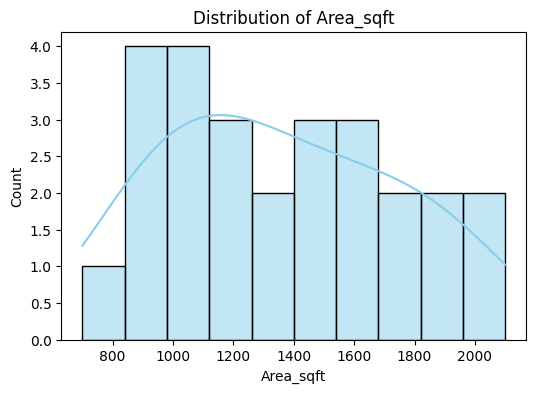

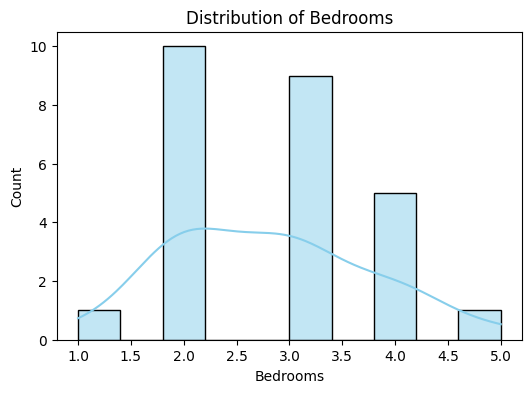

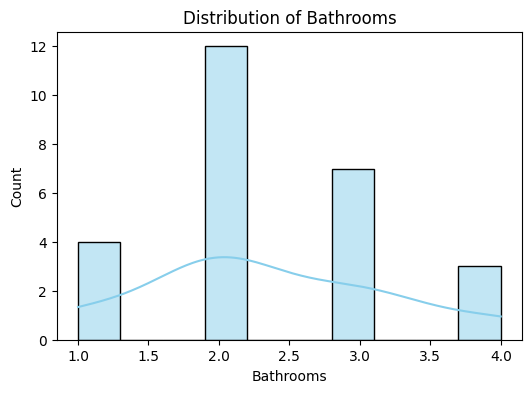

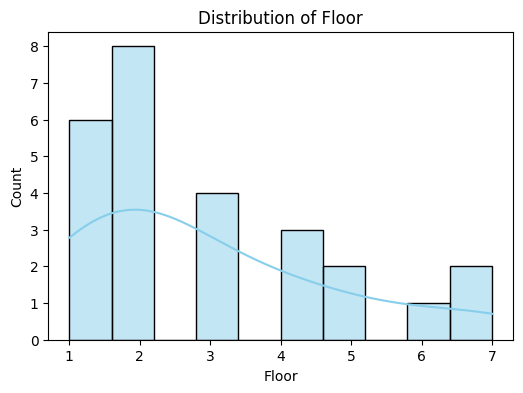

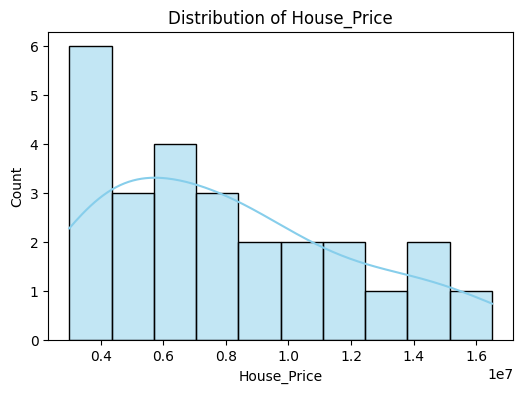

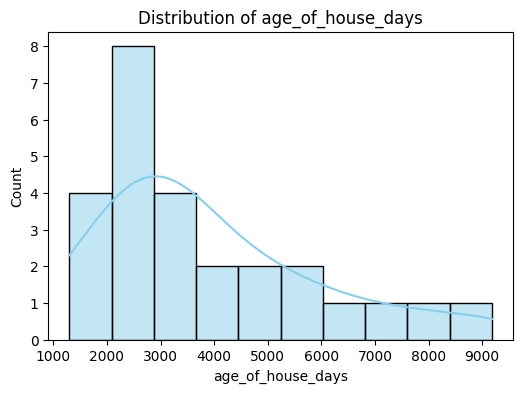

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(ml_df[col], kde=True, bins=10, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()




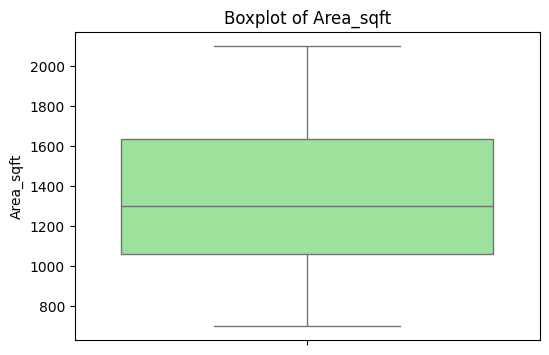

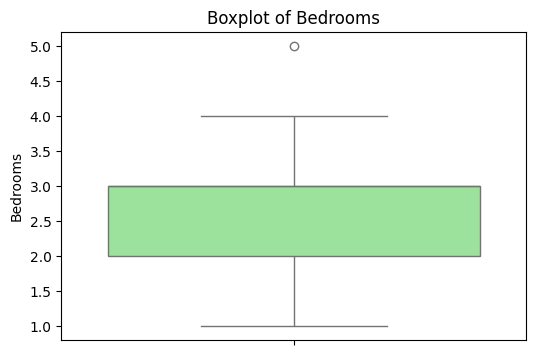

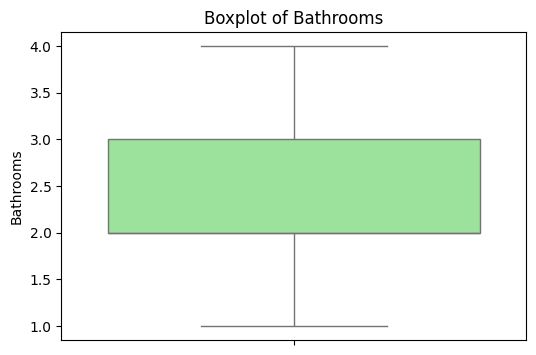

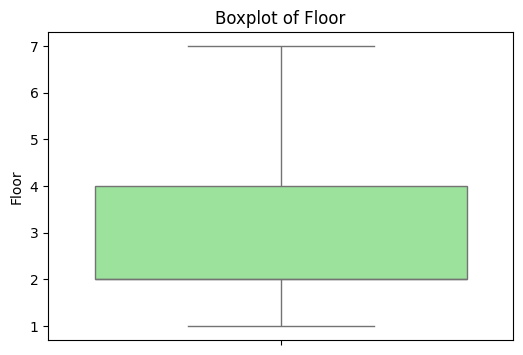

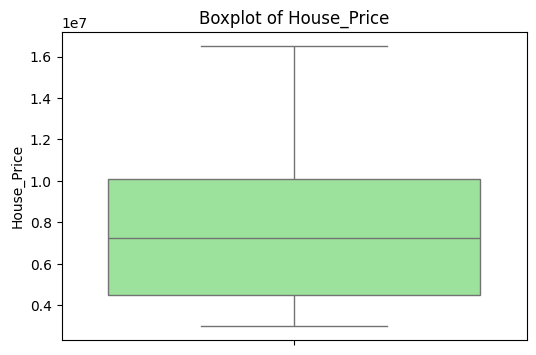

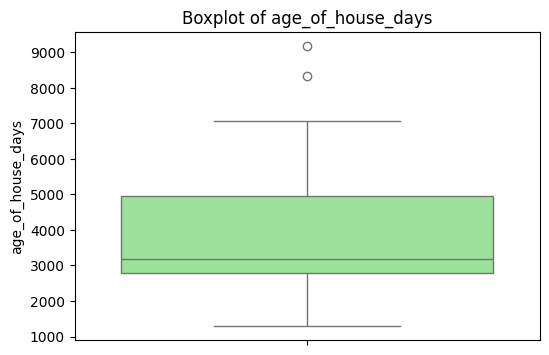

In [ ]:
# Boxplots (to check outliers)
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=ml_df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
for col in num_cols:
    print(col, ":", df[col].skew())


Area_sqft : 0.2448633977708976
Bedrooms : 0.41357545926209366
Bathrooms : 0.32206780789739403
Floor : 0.9691046281538269
House_Price : 0.6685451039072801
age_of_house_days : 1.1619255845080547


In [ ]:
df[num_cols].describe()


,Area_sqft,Bedrooms,Bathrooms,Floor,House_Price,age_of_house_days
count,26.000000,26.000000,26.000000,26.000000,2.600000e+01,26.000000
mean,1355.769231,2.807692,2.346154,2.923077,8.000000e+06,3901.269231
std,391.235715,0.938903,0.891843,1.831351,3.885048e+06,2049.970625
min,700.000000,1.000000,1.000000,1.000000,3.000000e+06,1297.000000
25%,1062.500000,2.000000,2.000000,2.000000,4.525000e+06,2792.000000
50%,1300.000000,3.000000,2.000000,2.000000,7.250000e+06,3180.500000
75%,1637.500000,3.000000,3.000000,4.000000,1.010000e+07,4965.750000
max,2100.000000,5.000000,4.000000,7.000000,1.650000e+07,9184.000000


In [ ]:
round(df[num_cols].describe(),2)

,Area_sqft,Bedrooms,Bathrooms,Floor,House_Price,age_of_house_days
count,26.00,26.00,26.00,26.00,26.00,26.00
mean,1355.77,2.81,2.35,2.92,8000000.00,3901.27
std,391.24,0.94,0.89,1.83,3885048.26,2049.97
min,700.00,1.00,1.00,1.00,3000000.00,1297.00
25%,1062.50,2.00,2.00,2.00,4525000.00,2792.00
50%,1300.00,3.00,2.00,2.00,7250000.00,3180.50
75%,1637.50,3.00,3.00,4.00,10100000.00,4965.75
max,2100.00,5.00,4.00,7.00,16500000.00,9184.00


In [ ]:
ml_df = ml_df.copy()  # avoids SettingWithCopyWarning


In [ ]:
def cap_outliers_numeric(df, numeric_cols):
    """
    Caps outliers in all numeric columns using 1.5*IQR method.
    Modifies the DataFrame in-place to avoid SettingWithCopyWarning.
    """
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Use .loc to modify safely
        df.loc[:, col] = df[col].clip(lower_limit, upper_limit)


In [ ]:
cap_outliers_numeric(ml_df, num_cols)

/tmp/ipykernel_795/1854096139.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4280.    2367.    1504.    6573.    3386.    2792.    8226.375 3305.
 2792.    5321.    7065.    2792.    1915.    4638.    3821.    8226.375
 1802.    2859.    5554.    5075.    1297.    2792.    2611.    3534.
 3056.    2792.   ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = df[col].clip(lower_limit, upper_limit)


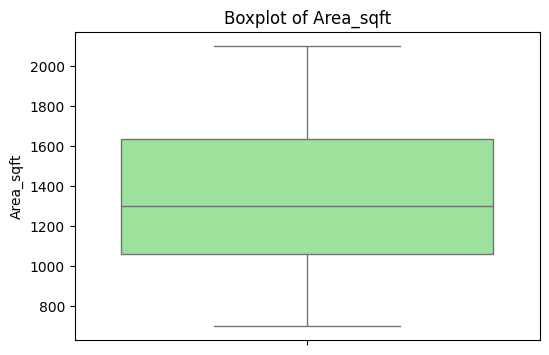

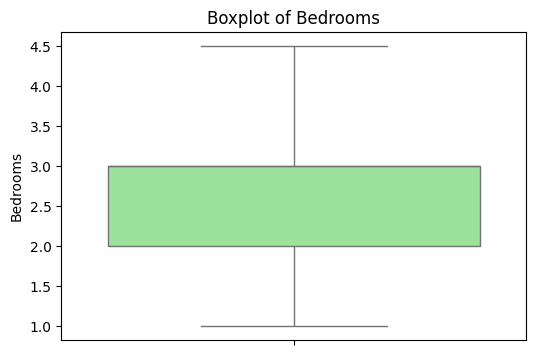

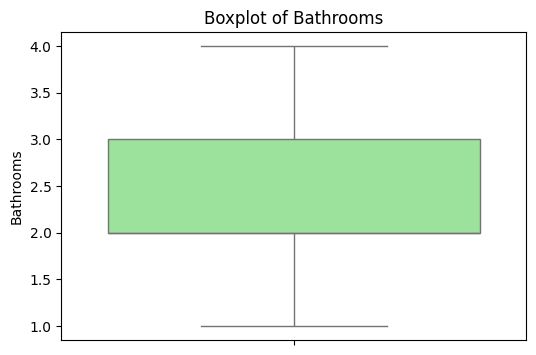

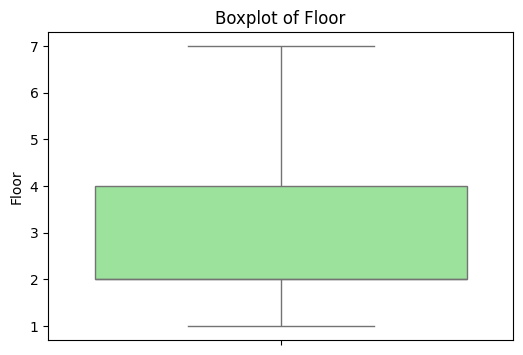

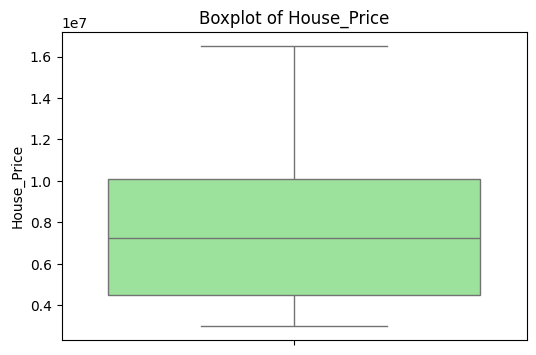

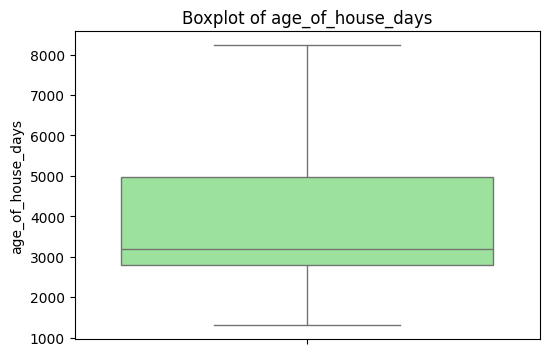

In [ ]:
# Boxplots (to check outliers)
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=ml_df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
for col in num_cols:
    print(col, ":", ml_df[col].skew())

Area_sqft : 0.2448633977708976
Bedrooms : 0.2026706191489879
Bathrooms : 0.32206780789739403
Floor : 0.9691046281538269
House_Price : 0.6685451039072801
age_of_house_days : 0.9973353859784891


# apply transformations columnn by column

In [ ]:
#skewness handling for floor,house_price , age_of_house_days

In [ ]:
#using cube root
ml_df['Floor'] = np.cbrt(ml_df['Floor'])
ml_df['House_Price'] = np.cbrt(ml_df['House_Price'])
ml_df['age_of_house_days'] = np.cbrt(ml_df['age_of_house_days'])

In [ ]:
for col in num_cols:
    print(col, ":", ml_df[col].skew())

Area_sqft : 0.2448633977708976
Bedrooms : 0.2026706191489879
Bathrooms : 0.32206780789739403
Floor : 0.3428545639147214
House_Price : 0.21707076102311726
age_of_house_days : 0.41404051637948774


/tmp/ipykernel_795/4057446716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ml_df, x=col, palette='pastel')


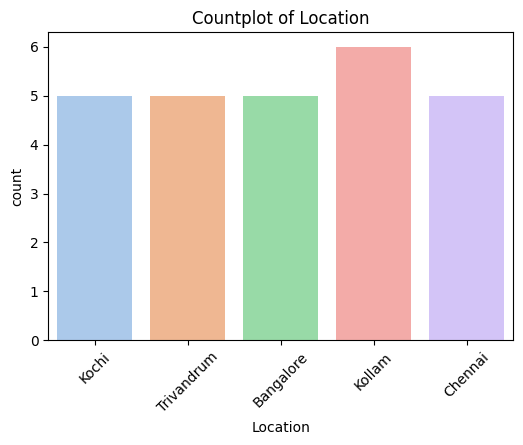

/tmp/ipykernel_795/4057446716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ml_df, x=col, palette='pastel')


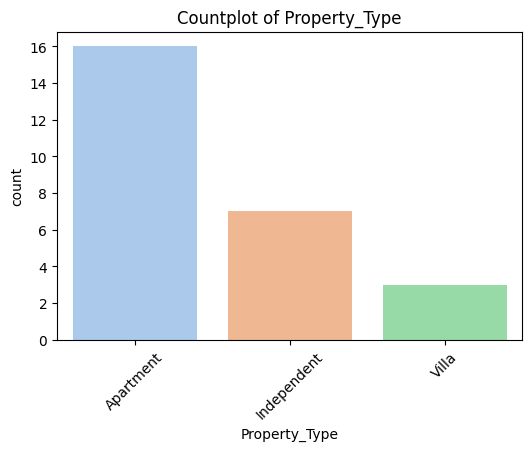

/tmp/ipykernel_795/4057446716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ml_df, x=col, palette='pastel')


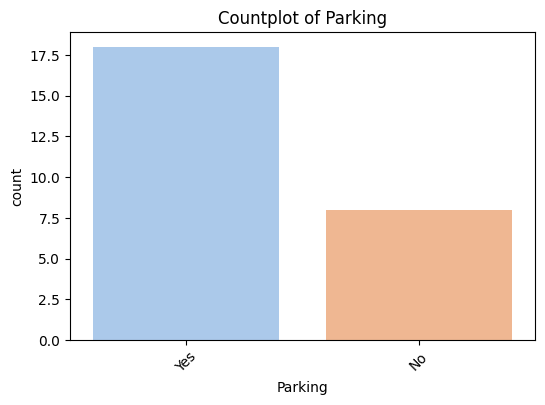

/tmp/ipykernel_795/4057446716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ml_df, x=col, palette='pastel')


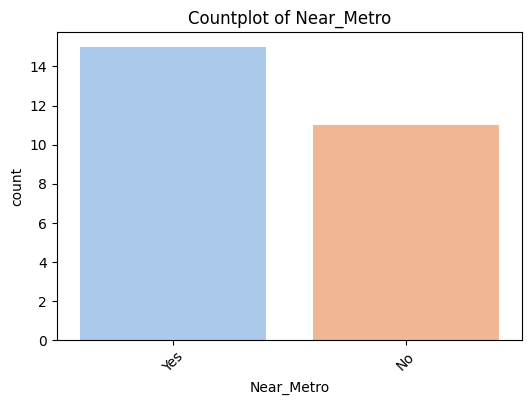

In [ ]:
# Countplots for categorical variables
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=ml_df, x=col, palette='pastel')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()


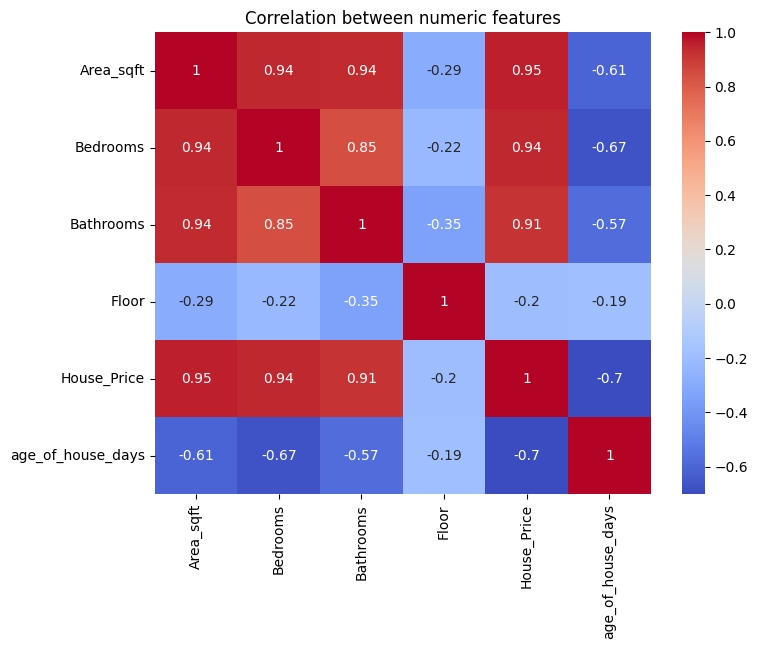

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(ml_df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between numeric features")
plt.show()


In [ ]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Floor,age_of_house_days,House_Price
count,26.000000,26.000000,26.000000,26.000000,26.000000,2.600000e+01
mean,1355.769231,2.807692,2.346154,2.923077,3901.269231,8.000000e+06
std,391.235715,0.938903,0.891843,1.831351,2049.970625,3.885048e+06
min,700.000000,1.000000,1.000000,1.000000,1297.000000,3.000000e+06
25%,1062.500000,2.000000,2.000000,2.000000,2792.000000,4.525000e+06
50%,1300.000000,3.000000,2.000000,2.000000,3180.500000,7.250000e+06
75%,1637.500000,3.000000,3.000000,4.000000,4965.750000,1.010000e+07
max,2100.000000,5.000000,4.000000,7.000000,9184.000000,1.650000e+07


In [ ]:
df[cat_cols]

,Location,Property_Type,Parking,Near_Metro
0,Kochi,Apartment,Yes,Yes
1,Trivandrum,Apartment,Yes,No
2,Bangalore,Independent,Yes,Yes
3,Kollam,Apartment,No,No
4,Chennai,Independent,Yes,Yes
5,Kochi,Apartment,Yes,Yes
6,Kollam,Apartment,No,No
7,Trivandrum,Apartment,Yes,Yes
8,Bangalore,Villa,Yes,Yes
9,Chennai,Independent,Yes,No


In [ ]:
one_hot_cols = ['Property_Type', 'Parking', 'Near_Metro']

ml_df = pd.get_dummies(
    ml_df,
    columns=one_hot_cols,
    drop_first=True, dtype=int
)


In [ ]:
ml_df.head(3)

,Area_sqft,Bedrooms,Bathrooms,Location,Floor,House_Price,age_of_house_days,Property_Type_Independent,Property_Type_Villa,Parking_Yes,Near_Metro_Yes
0,850.0,2.0,1.0,Kochi,1.442250,165.096362,16.236083,0,0,1,1
1,1200.0,3.0,2.0,Trivandrum,1.709976,183.709055,13.327011,0,0,1,0
2,1500.0,3.0,3.0,Bangalore,1.000000,213.997496,11.457309,1,0,1,1


In [ ]:
# Calculate mean house price per city
city_mean_price = ml_df.groupby('Location')['House_Price'].mean()

# Map mean price back to City column
ml_df['Location'] = ml_df['Location'].map(city_mean_price)

In [ ]:
ml_df.head(3)

,Area_sqft,Bedrooms,Bathrooms,Location,Floor,House_Price,age_of_house_days,Property_Type_Independent,Property_Type_Villa,Parking_Yes,Near_Metro_Yes
0,850.0,2.0,1.0,172.292363,1.442250,165.096362,16.236083,0,0,1,1
1,1200.0,3.0,2.0,194.933932,1.709976,183.709055,13.327011,0,0,1,0
2,1500.0,3.0,3.0,239.093504,1.000000,213.997496,11.457309,1,0,1,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'Area_sqft',
    'Bedrooms',
    'Bathrooms',
    'Floor',
    'age_of_house_days'
]
scaler = StandardScaler()
ml_df[scale_cols] = scaler.fit_transform(ml_df[scale_cols])

In [ ]:
ml_df.head(3)

,Area_sqft,Bedrooms,Bathrooms,Location,Floor,House_Price,age_of_house_days,Property_Type_Independent,Property_Type_Villa,Parking_Yes,Near_Metro_Yes
0,-1.318350,-0.897046,-1.539298,172.292363,0.246891,165.096362,0.382688,0,0,1,1
1,-0.406032,0.240671,-0.395820,194.933932,1.188585,183.709055,-0.791832,0,0,1,0
2,0.375955,0.240671,0.747659,239.093504,-1.308667,213.997496,-1.546713,1,0,1,1


# this is our final data for ml